In [12]:
!pip install opendatasets --quiet
import opendatasets as od
kaggleURL = "https://www.kaggle.com/datasets/"
od.download(kaggleURL + "marquis03/bean-leaf-lesions-classification")

Skipping, found downloaded files in "./bean-leaf-lesions-classification" (use force=True to force download)


In [13]:
import torch
import torch.nn as nn
from torch.optim import Adam
import torchvision.transforms as transforms
from torchvision import models #import pretrained models in PyTorch library
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

In [16]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [22]:
train_df = pd.read_csv("bean-leaf-lesions-classification/train.csv")
val_df = pd.read_csv("bean-leaf-lesions-classification/val.csv")

In [36]:
print(train_df.head(5))
train_df.shape

                            image:FILE  category
0   train/healthy/healthy_train.98.jpg         0
1  train/healthy/healthy_train.148.jpg         0
2  train/healthy/healthy_train.306.jpg         0
3  train/healthy/healthy_train.305.jpg         0
4   train/healthy/healthy_train.40.jpg         0


(1034, 2)

In [35]:
print(val_df.head(5))
val_df.shape

                       image:FILE  category
0  val/healthy/healthy_val.25.jpg         0
1  val/healthy/healthy_val.32.jpg         0
2   val/healthy/healthy_val.3.jpg         0
3  val/healthy/healthy_val.16.jpg         0
4  val/healthy/healthy_val.10.jpg         0


(133, 2)

In [37]:
data_df = pd.concat([train_df, val_df], ignore_index=True)
print(data_df.head())
print()
data_df.shape

                            image:FILE  category
0   train/healthy/healthy_train.98.jpg         0
1  train/healthy/healthy_train.148.jpg         0
2  train/healthy/healthy_train.306.jpg         0
3  train/healthy/healthy_train.305.jpg         0
4   train/healthy/healthy_train.40.jpg         0



(1167, 2)

In [46]:
print(f"Classes are: {data_df['category'].unique()}")
print()
print(f"Classes distribution are: {data_df['category'].value_counts()}")

Classes are: [0 1 2]

Classes distribution are: category
2    393
1    389
0    385
Name: count, dtype: int64


In [49]:
train_data.shape

(817, 2)

In [69]:
train_data = data_df.sample(frac=0.7, random_state = 7)
test_data = data_df.drop(train_data.index)

In [70]:
validation_data.shape

(350, 2)

In [136]:
label_encoder = LabelEncoder()

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float),
])

In [138]:
label_encoder = LabelEncoder()
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),   # converts to tensor and normalizes to [0,1]
])

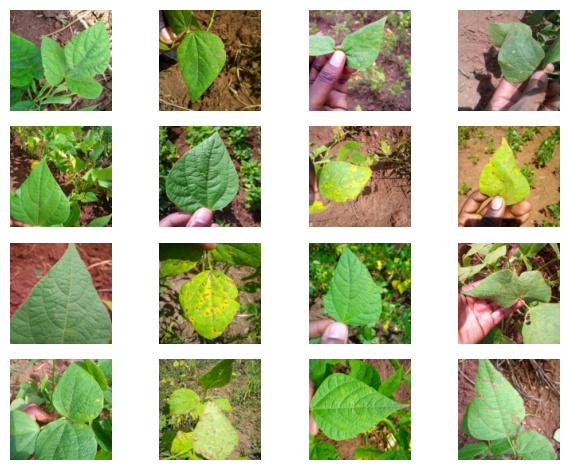

In [146]:
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = torch.tensor(label_encoder.fit_transform(dataframe['category'])).to(device) #***

    def __len__(self):
        return self.dataframe.shape[0]

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        full_path = "bean-leaf-lesions-classification/" + img_path
        #print(full_path)
        label = self.labels[idx]
        image = Image.open(full_path).convert('RGB')
        if self.transform:
            image = self.transform(image).to(device) #Normalizes the image  from [0, 255] to [0.0, 1.0]
        return image, label


train_dataset = CustomImageDataset(dataframe = train_data, transform = transform)
test_dataset = CustomImageDataset(dataframe = test_data, transform = transform)


n_rows = 4
n_cols = 4
f, axarr = plt.subplots(n_rows, n_cols)
for row in range(n_rows):
    for col in range(n_cols):
        #image = train_dataset[np.random.randint(0, len(train_dataset))][0].cpu()
        image = train_dataset[np.random.randint(0,train_dataset.__len__())][0].cpu() 
        #WRONG: axarr[row, col].imshow((image*255).squeeze().permute(1,2,0))  #***
        axarr[row, col].imshow((image * 255).permute(1, 2, 0).byte())  # convert back to [0,255] for display  #***
        axarr[row, col].axis('off')

plt.tight_layout()
plt.show()

In [171]:
LR = 1e-3 #***
BATCH_SIZE = 4
EPOCHS = 15

#SEQUENCE of loading the data:
#train_data (train_df)
#train_dataset (train_data)
#train DataLoader(train_dataset)

train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = True)

In [172]:
#Pretrained Model
GoogLeNet_model = models.googlenet(weights = 'DEFAULT') #***
for param in GoogLeNet_model.parameters(): #***
    param.requires_grad = True

#To train only the final layer:
#for param in googlenet_model.parameters():
#    param.requires_grad = False  # Freeze all layers
#googlenet_model.fc.requires_grad = True

In [173]:
GoogLeNet_model.fc

Linear(in_features=1024, out_features=1000, bias=True)

In [174]:
num_classes = len(data_df['category'].unique())

In [175]:
GoogLeNet_model.fc = torch.nn.Linear(GoogLeNet_model.fc.in_features, num_classes)
GoogLeNet_model.to(device)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [176]:
#Define Loss function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = Adam(GoogLeNet_model.parameters(), lr=LR)

In [177]:
total_loss_train_plot = []
total_accuracy_train_plot = []

In [178]:
for epoch in range (EPOCHS):
    total_loss_train = 0
    total_accuracy_train = 0

    for (inputs, labels) in train_loader:
        optimizer.zero_grad()
        outputs = GoogLeNet_model(inputs)
        train_loss = criterion(outputs, labels)
        total_loss_train += train_loss.item()
        train_loss.backward()

        train_accuracy = (torch.argmax(outputs, axis = 1) == labels).sum().item()
        total_accuracy_train += train_accuracy
        optimizer.step()

    total_loss_train_plot.append(round(total_loss_train/1000, 4))
    total_accuracy_train_plot.append(round(total_accuracy_train/(train_dataset.__len__())*100, 4))
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {round(total_loss_train/100, 4)} Train Accuracy {round((total_accuracy_train)/train_dataset.__len__() * 100, 4)}%')
    print()

Epoch 1/15, Train Loss: 1.6881 Train Accuracy 65.7283%

Epoch 2/15, Train Loss: 1.3112 Train Accuracy 74.6634%

Epoch 3/15, Train Loss: 1.021 Train Accuracy 81.8849%

Epoch 4/15, Train Loss: 0.8956 Train Accuracy 84.8225%

Epoch 5/15, Train Loss: 0.7395 Train Accuracy 88.3721%

Epoch 6/15, Train Loss: 0.764 Train Accuracy 87.8825%

Epoch 7/15, Train Loss: 0.601 Train Accuracy 88.9841%

Epoch 8/15, Train Loss: 0.6061 Train Accuracy 91.0649%

Epoch 9/15, Train Loss: 0.5186 Train Accuracy 91.1873%

Epoch 10/15, Train Loss: 0.5822 Train Accuracy 90.3305%

Epoch 11/15, Train Loss: 0.646 Train Accuracy 88.4945%

Epoch 12/15, Train Loss: 0.4138 Train Accuracy 94.2472%

Epoch 13/15, Train Loss: 0.3804 Train Accuracy 93.5129%

Epoch 14/15, Train Loss: 0.3337 Train Accuracy 94.492%

Epoch 15/15, Train Loss: 0.3734 Train Accuracy 94.2472%



In [181]:
with torch.no_grad():
    total_loss_test = 0
    total_accuracy_test = 0
    for index, (input, labels) in enumerate(test_loader):

        prediction = GoogLeNet_model(input)

        accuracy = (torch.argmax(prediction, axis = 1) == labels).sum().item()
        total_accuracy_test += accuracy

print(f"Accuracy Score is: {round((total_accuracy_test/test_dataset.__len__())*100,2)}%")

Accuracy Score is: 83.71%


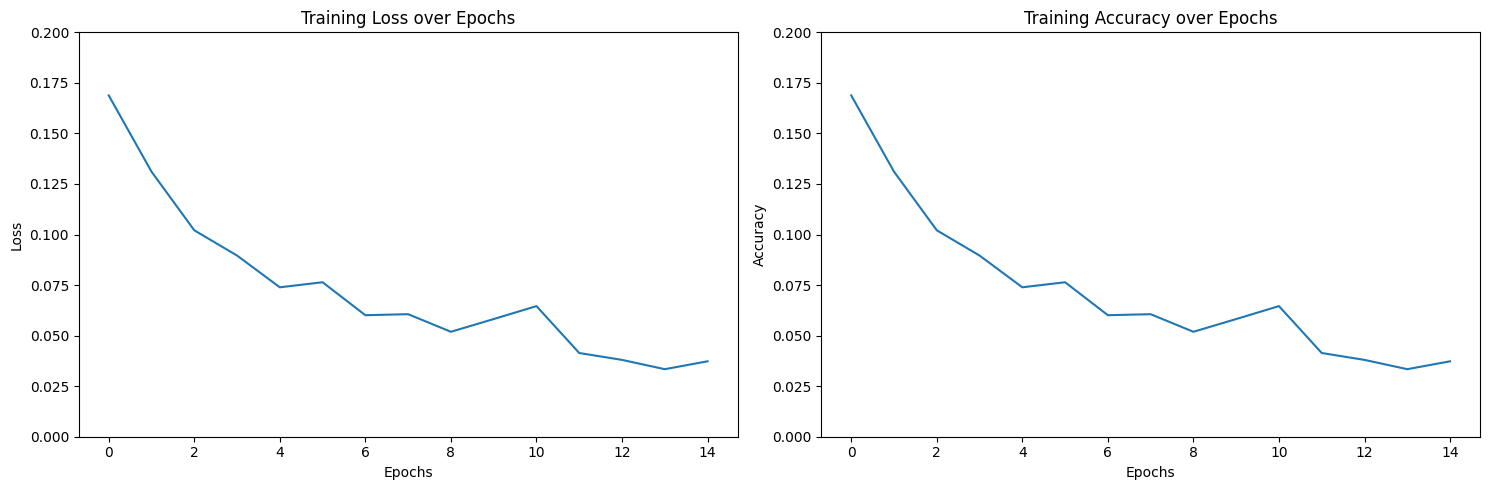

In [188]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize=(15,5))

axs[0].plot(total_loss_train_plot, label = 'Training Loss')
axs[0].set_title('Training Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_ylim([0,0.2])
axs[0].legend

axs[1].plot(total_loss_train_plot, label = 'Training Accuracy')
axs[1].set_title('Training Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim([0,0.2])
axs[1].legend

plt.tight_layout()

plt.show()